In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('Hruthika_lakshmi_25BTIT148.csv')

df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1.0,Tesla,2016.0,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,2.0,BMW,2018.0,4.4,Electric,Manual,143190.0,Used,14679.61,5 Series
2,3.0,Audi,2013.0,4.5,Electric,Manual,181601.0,New,44402.61,A4
3,4.0,Tesla,2011.0,4.1,Diesel,Automatic,68682.0,New,86374.33,Model Y
4,5.0,Ford,2009.0,2.6,Diesel,Manual,223009.0,Like New,73577.10,Mustang


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2250 non-null   float64
 1   Brand         2250 non-null   object 
 2   Year          2250 non-null   float64
 3   Engine Size   2250 non-null   float64
 4   Fuel Type     2250 non-null   object 
 5   Transmission  2250 non-null   object 
 6   Mileage       2250 non-null   float64
 7   Condition     2250 non-null   object 
 8   Price         2250 non-null   float64
 9   Model         2250 non-null   object 
dtypes: float64(5), object(5)
memory usage: 195.4+ KB


In [5]:
df.isnull().sum()

Car ID          250
Brand           250
Year            250
Engine Size     250
Fuel Type       250
Transmission    250
Mileage         250
Condition       250
Price           250
Model           250
dtype: int64

In [6]:
yeni_isimler = {
    'Car ID': 'Araba_ID',
    'Brand': 'Marka',
    'Year': 'Yil',
    'Engine Size': 'Motor_Hacmi',
    'Fuel Type': 'Yakit_Tipi',
    'Transmission': 'Vites',
    'Mileage': 'Kilometre',
    'Condition': 'Durum',
    'Price': 'Fiyat',
    'Model': 'Model',
}


df.rename(columns=yeni_isimler, inplace=True)



In [7]:
df.head(3)

,Araba_ID,Marka,Yil,Motor_Hacmi,Yakit_Tipi,Vites,Kilometre,Durum,Fiyat,Model
0,1.0,Tesla,2016.0,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,2.0,BMW,2018.0,4.4,Electric,Manual,143190.0,Used,14679.61,5 Series
2,3.0,Audi,2013.0,4.5,Electric,Manual,181601.0,New,44402.61,A4


In [9]:
df['Kilometre'] = df['Kilometre']*1.60934

df['Kilometre'] = df['Kilometre'].round(0)

df.head(5)

,Araba_ID,Marka,Yil,Motor_Hacmi,Yakit_Tipi,Vites,Kilometre,Durum,Fiyat,Model
0,1.0,Tesla,2016.0,2.3,Petrol,Manual,297412.0,New,26613.92,Model X
1,2.0,BMW,2018.0,4.4,Electric,Manual,370858.0,Used,14679.61,5 Series
2,3.0,Audi,2013.0,4.5,Electric,Manual,470342.0,New,44402.61,A4
3,4.0,Tesla,2011.0,4.1,Diesel,Automatic,177885.0,New,86374.33,Model Y
4,5.0,Ford,2009.0,2.6,Diesel,Manual,577587.0,Like New,73577.10,Mustang


In [11]:
df.dropna(inplace=True)

df.shape

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2250 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Araba_ID     2250 non-null   float64
 1   Marka        2250 non-null   object 
 2   Yil          2250 non-null   float64
 3   Motor_Hacmi  2250 non-null   float64
 4   Yakit_Tipi   2250 non-null   object 
 5   Vites        2250 non-null   object 
 6   Kilometre    2250 non-null   float64
 7   Durum        2250 non-null   object 
 8   Fiyat        2250 non-null   float64
 9   Model        2250 non-null   object 
dtypes: float64(5), object(5)
memory usage: 193.4+ KB


In [12]:
df.describe() 

,Araba_ID,Yil,Motor_Hacmi,Kilometre,Fiyat
count,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000
mean,1251.243556,2011.577778,3.485467,389107.984000,52506.874391
std,725.637358,6.980468,1.427690,228308.248883,27232.417079
min,1.000000,2000.000000,1.000000,39.000000,5011.270000
25%,627.250000,2005.000000,2.300000,184350.000000,28985.052500
50%,1249.500000,2012.000000,3.450000,387880.000000,53485.240000
75%,1875.250000,2018.000000,4.700000,586108.750000,75560.340000
max,2500.000000,2023.000000,6.000000,776907.000000,99982.590000


In [14]:
!pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


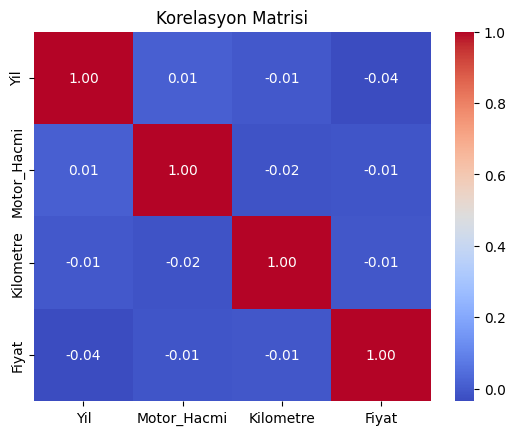

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sayisal_sutunlar = df[['Yil', 'Motor_Hacmi', 'Kilometre', 'Fiyat']]
korelasyon = sayisal_sutunlar.corr()

sns.heatmap(korelasyon, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasyon Matrisi')
plt.show()

In [17]:
df_temiz = df.drop(columns=['Araba_ID', 'Model'])

df.encoded = pd.get_dummies(df_temiz, columns=['Marka', 'Yakit_Tipi', 'Vites', 'Durum'], drop_first=True)

df.encoded.head(3)

C:\Users\mehme\AppData\Local\Temp\ipykernel_10424\478655374.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.encoded = pd.get_dummies(df_temiz, columns=['Marka', 'Yakit_Tipi', 'Vites', 'Durum'], drop_first=True)


,Yil,Motor_Hacmi,Kilometre,Fiyat,Marka_BMW,Marka_Ford,Marka_Honda,Marka_Mercedes,Marka_Tesla,Marka_Toyota,Yakit_Tipi_Electric,Yakit_Tipi_Hybrid,Yakit_Tipi_Petrol,Vites_Automatic,Vites_Manual,Durum_New,Durum_Used
0,2016.0,2.3,297412.0,26613.92,False,False,False,False,True,False,False,False,True,False,True,True,False
1,2018.0,4.4,370858.0,14679.61,True,False,False,False,False,False,True,False,False,False,True,False,True
2,2013.0,4.5,470342.0,44402.61,False,False,False,False,False,False,True,False,False,False,True,True,False


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x = df.encoded.drop(columns=['Fiyat'])
y=df.encoded['Fiyat']


x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(x_train, y_train)

print("Model eğitildi.")


Model eğitildi.


In [20]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(x_test)

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

print(f"modelin R2 skoru: {r2:.4f}")
print(f"modelin MAE skoru: {mae:.4f}")

modelin R2 skoru: 0.0018
modelin MAE skoru: 23400.8922
